### Weights & Biases Setup
This section installs the `wandb` library and logs into your Weights & Biases account. It attempts a non-interactive login using the `WANDB_API_KEY` stored in Colab secrets. If the key is not found, it will attempt an interactive login.

In [7]:
# Install wandb library
!pip install wandb -qqq

# import colab user data
from google.colab import userdata
import wandb

# Log in to wandb non-interactively using the API key from Colab secrets
wandb_api_key = userdata.get('WANDB_API_KEY')
if wandb_api_key:
  print("WANDB_API_KEY found. Attempting non-interactive login to Weights & Biases.")
  wandb.login(key=wandb_api_key)
else:
  print("WANDB_API_KEY not found in environment variables. Attempting interactive login.")
  print("Please ensure your W&B API key is set as a secret named 'WANDB_API_KEY' in Colab or your environment.")
  wandb.login()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


WANDB_API_KEY found. Attempting non-interactive login to Weights & Biases.


### GitHub Repository Cloning
This section clones the specified GitHub repository. It attempts to use a GitHub Personal Access Token (`GITHUB_TOKEN`) stored in Colab secrets for private repositories. If no token is found, it will attempt to clone the repository directly, which will only succeed for public repositories or if credentials are otherwise configured.

In [3]:
import os

# GitHub repository cloning
# If the repository is private, a Personal Access Token (PAT) is required.
# Assuming 'github' (which is the GITHUB_TOKEN) is available as a secret.
github_token = userdata.get('github')
repo_url = "https://github.com/gbera23-dev/Machine-Learning.git"

if github_token:
  print("GITHUB_TOKEN found. Attempting to clone GitHub repository using token.")
  # Embed the token in the URL for cloning private repos
  !git clone https://{github_token}@github.com/gbera23-dev/Machine-Learning.git
else:
  print("GITHUB_TOKEN not found in environment variables. Attempting to clone repository without explicit token.")
  print("If the repository is private, please ensure your GitHub Personal Access Token is set as a secret named 'github' in Colab or your environment.")
  !git clone {repo_url}

# Verify the repository was cloned
if os.path.exists("Machine-Learning"):
    print("Repository 'Machine-Learning' cloned successfully.")
else:
    print("Failed to clone repository 'Machine-Learning'. Please check your GitHub token if it's a private repo.")

GITHUB_TOKEN found. Attempting to clone GitHub repository using token.
Cloning into 'Machine-Learning'...
remote: Enumerating objects: 172, done.
remote: Counting objects: 100% (172/172), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 172 (delta 74), reused 123 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (172/172), 1.02 MiB | 14.98 MiB/s, done.
Resolving deltas: 100% (74/74), done.
Repository 'Machine-Learning' cloned successfully.


In [4]:
# Install the Kaggle API client
!pip install kaggle -qqq

### Kaggle authorization

In [12]:
%cd Machine-Learning/Assignment4

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


%ls

[Errno 2] No such file or directory: 'Machine-Learning/Assignment4'
/content/Machine-Learning/Assignment4
model_files/  README.md


### Download Kaggle Competition Data

Now, we can download the data for the 'Challenges in Representation Learning, Facial Expression Recognition Challenge' competition. The competition name on Kaggle is `challenges-in-representation-learning-facial-expression-recognition-challenge`.

In [13]:
# Define the competition name
competition_name = 'challenges-in-representation-learning-facial-expression-recognition-challenge'

# Download the competition data
!kaggle competitions download -c {competition_name}

100% 285M/285M [00:17<00:00, 16.7MB/s]



### Unzip the Downloaded Data

In [14]:
zip_file_name = f"{competition_name}.zip"

!unzip -q {zip_file_name} -d "./{competition_name}_data"

!ls -F "./{competition_name}_data"

print(f"Data unzipped to ./{competition_name}_data")

example_submission.csv	fer2013.tar.gz	icml_face_data.csv  test.csv  train.csv
Data unzipped to ./challenges-in-representation-learning-facial-expression-recognition-challenge_data


### Change directory to Machine-Learning

In [ ]:
# %cd Machine-Learning

[Errno 2] No such file or directory: 'Machine-Learning'
/content/Machine-Learning/Assignment4


## 1. Exploratory Data Analysis (EDA)
We will load the dataset and visualize the classes to understand the distribution of emotions.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the data
data_path = './challenges-in-representation-learning-facial-expression-recognition-challenge_data/icml_face_data.csv'
df = pd.read_csv(data_path)

# Display basic info
print(f"Dataset Shape: {df.shape}")
display(df.head())

# Check the usage split (Training, PublicTest, PrivateTest)
print("\nUsage distribution:")
print(df[' Usage'].value_counts())

Dataset Shape: (35887, 3)


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...



Usage distribution:
 Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


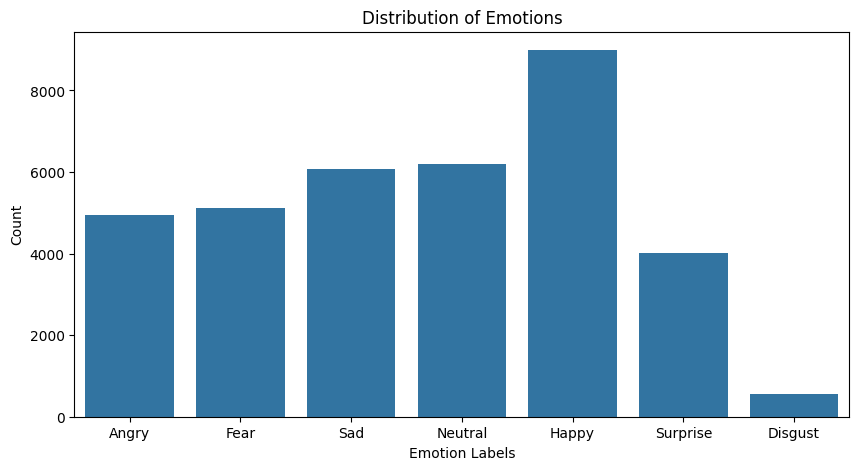

In [16]:
# Emotion mapping
emotion_map = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Visualize Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=df['emotion'].map(emotion_map))
plt.title('Distribution of Emotions')
plt.xlabel('Emotion Labels')
plt.ylabel('Count')
plt.show()

Sample images from the dataset:


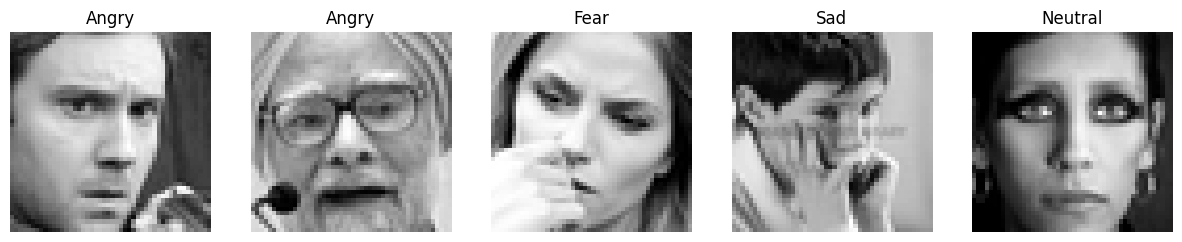

In [17]:
def plot_samples(df, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):

        pixels = df.iloc[i][' pixels'].split()
        image = np.array(pixels, dtype='float32').reshape(48, 48)

        plt.subplot(1, num_samples, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(emotion_map[df.iloc[i]['emotion']])
        plt.axis('off')
    plt.show()

print("Sample images from the dataset:")
plot_samples(df)

### 1.2 Deep Dive into Data Structure
Let's look at the raw training data structure and the distribution of pixel intensities across all images.

Raw Pixel Data Example (First 50 characters of the first row):
70 80 82 72 58 58 60 63 54 58 60 48 89 115 121 119...


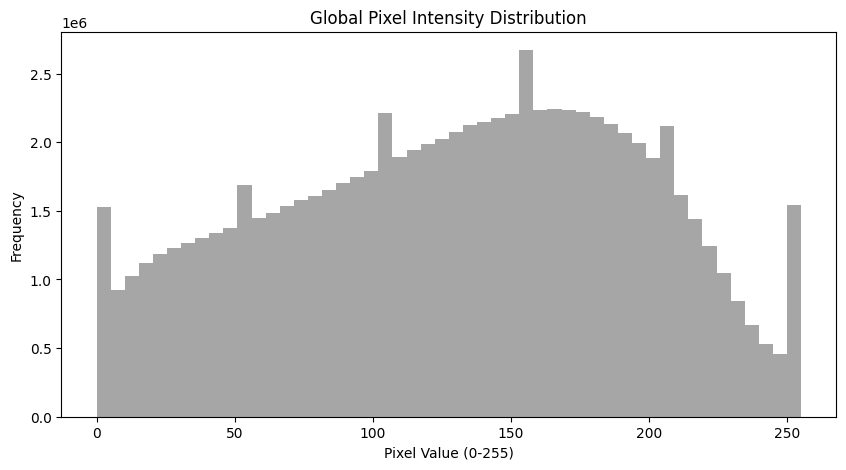

In [18]:
print("Raw Pixel Data Example (First 50 characters of the first row):")
print(df.loc[0, ' pixels'][:50] + "...")

all_pixels = np.array([np.fromstring(x, dtype=int, sep=' ') for x in df[' pixels']])

plt.figure(figsize=(10, 5))
plt.hist(all_pixels.flatten(), bins=50, color='gray', alpha=0.7)

plt.title('Global Pixel Intensity Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')
plt.show()

## 2. Data Preparation
We will create a custom PyTorch Dataset to handle the conversion of pixel strings to tensors and apply basic normalization.

In [21]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Extract pixels and label
        pixels = self.df.iloc[idx][' pixels'].split()
        image = np.array(pixels, dtype='float32').reshape(48, 48)
        label = int(self.df.iloc[idx]['emotion'])

        # Add channel dimension (H, W) -> (H, W, C) for transforms
        image = image[:, :, np.newaxis] / 255.0

        if self.transform:
            image = self.transform(image)

        return image, label

# Define basic transforms
train_transform = transforms.Compose([
    transforms.ToTensor(),
    # Note: We can add augmentation here later
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Split the dataframe based on ' Usage'
train_df = df[df[' Usage'] == 'Training']
val_df = df[df[' Usage'] == 'PublicTest']

# Initialize Datasets
train_dataset = FERDataset(train_df, transform=train_transform)
val_dataset = FERDataset(val_df, transform=val_transform)

# Create Dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"DataLoaders created with {len(train_dataset)} training and {len(val_dataset)} validation samples.")

DataLoaders created with 28709 training and 3589 validation samples.


## 3. Model Development
### 3.1 Baseline CNN
We define a simple CNN architecture to start our experiments.

In [22]:
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(BaselineCNN, self).__init__()
        # Convolutional Layer 1: 1 input channel (grayscale), 32 filters, 3x3 kernel
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # Convolutional Layer 2: 32 input, 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # After two 2x2 pools, 48x48 becomes 12x12
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 64 * 12 * 12)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineCNN(num_classes=7).to(device)

print(f"Model initialized on device: {device}")

Model initialized on device: cuda


### 3.2 Define Loss Function and Optimizer
We will use CrossEntropyLoss (standard for classification) and the Adam optimizer.

In [27]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


### 3.4 Training Loop
We iterate through the training data, update the model weights, and log metrics to W&B.

Create sweep with ID: 9rmp2w7s
Sweep URL: https://wandb.ai/gbera23-free-university-of-tbilisi-/facial-expression-recognition/sweeps/9rmp2w7s


wandb: Agent Starting Run: l3g5nd8u with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.01
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: rosy-sweep-1 | Epoch [1/5], Loss: 1.8395
Run: rosy-sweep-1 | Epoch [2/5], Loss: 1.8123
Run: rosy-sweep-1 | Epoch [3/5], Loss: 1.8118
Run: rosy-sweep-1 | Epoch [4/5], Loss: 1.8108
Run: rosy-sweep-1 | Epoch [5/5], Loss: 1.8106


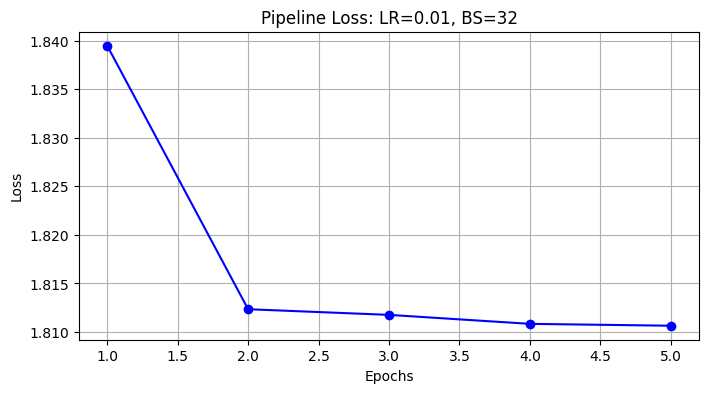

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.01_bs32.pth


epoch,▁▃▅▆█
train_loss,█▁▁▁▁
epoch,5
train_loss,1.81064


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: m997irxv with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: wobbly-sweep-2 | Epoch [1/5], Loss: 1.6692
Run: wobbly-sweep-2 | Epoch [2/5], Loss: 1.5726
Run: wobbly-sweep-2 | Epoch [3/5], Loss: 1.5241
Run: wobbly-sweep-2 | Epoch [4/5], Loss: 1.4983
Run: wobbly-sweep-2 | Epoch [5/5], Loss: 1.4624


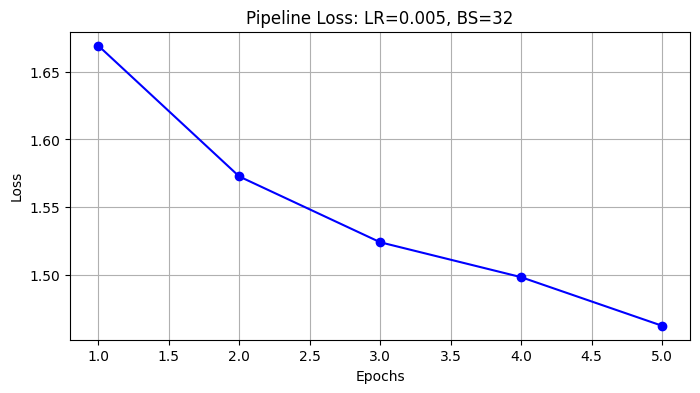

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.005_bs32.pth


epoch,▁▃▅▆█
train_loss,█▅▃▂▁
epoch,5
train_loss,1.46242


wandb: Agent Starting Run: xflo9his with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: floral-sweep-3 | Epoch [1/5], Loss: 1.5332
Run: floral-sweep-3 | Epoch [2/5], Loss: 1.2910
Run: floral-sweep-3 | Epoch [3/5], Loss: 1.1569
Run: floral-sweep-3 | Epoch [4/5], Loss: 1.0379
Run: floral-sweep-3 | Epoch [5/5], Loss: 0.9111


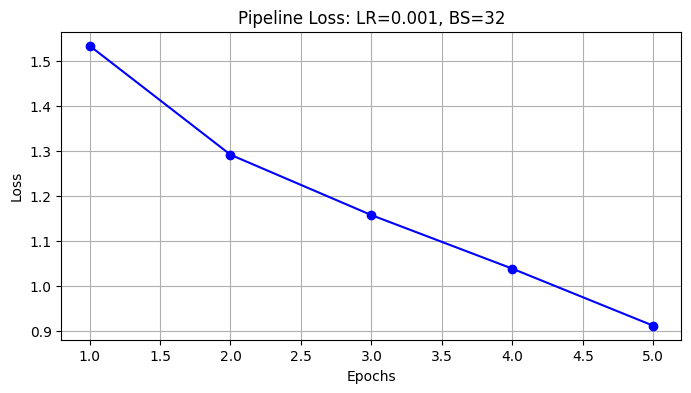

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.001_bs32.pth


epoch,▁▃▅▆█
train_loss,█▅▄▂▁
epoch,5
train_loss,0.91112


wandb: Agent Starting Run: tpq11wos with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.0005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: neat-sweep-4 | Epoch [1/5], Loss: 1.5968
Run: neat-sweep-4 | Epoch [2/5], Loss: 1.3785
Run: neat-sweep-4 | Epoch [3/5], Loss: 1.2680
Run: neat-sweep-4 | Epoch [4/5], Loss: 1.1800
Run: neat-sweep-4 | Epoch [5/5], Loss: 1.0973


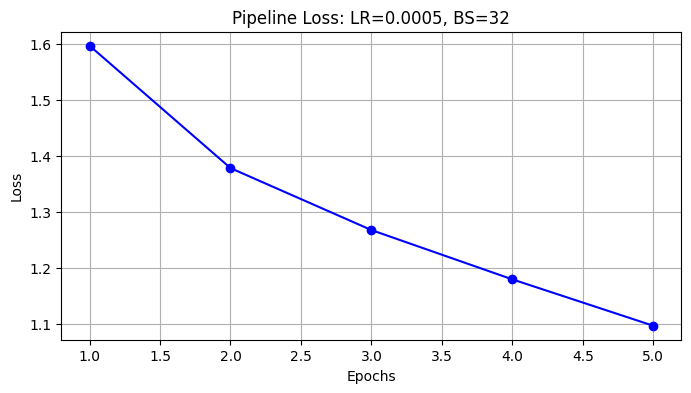

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.0005_bs32.pth


epoch,▁▃▅▆█
train_loss,█▅▃▂▁
epoch,5
train_loss,1.09733


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: mfkg1xji with config:
wandb: 	batch_size: 32
wandb: 	learning_rate: 0.0001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: rich-sweep-5 | Epoch [1/5], Loss: 1.7095
Run: rich-sweep-5 | Epoch [2/5], Loss: 1.5820
Run: rich-sweep-5 | Epoch [3/5], Loss: 1.5132
Run: rich-sweep-5 | Epoch [4/5], Loss: 1.4619
Run: rich-sweep-5 | Epoch [5/5], Loss: 1.4184


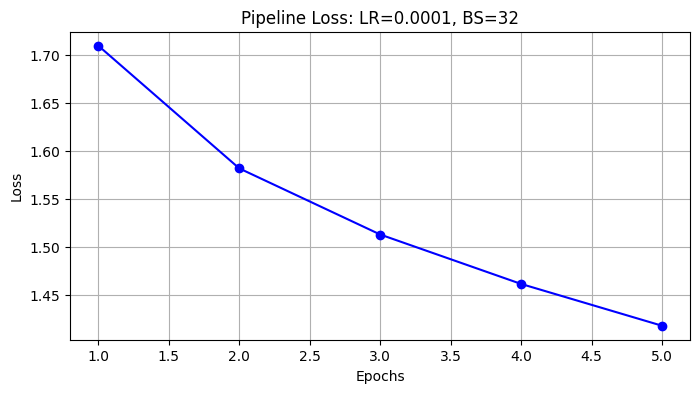

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.0001_bs32.pth


epoch,▁▃▅▆█
train_loss,█▅▃▂▁
epoch,5
train_loss,1.4184


wandb: Agent Starting Run: e2u6ffby with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.01
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: dark-sweep-6 | Epoch [1/5], Loss: 1.9750
Run: dark-sweep-6 | Epoch [2/5], Loss: 1.8124
Run: dark-sweep-6 | Epoch [3/5], Loss: 1.8123
Run: dark-sweep-6 | Epoch [4/5], Loss: 1.8118
Run: dark-sweep-6 | Epoch [5/5], Loss: 1.8112


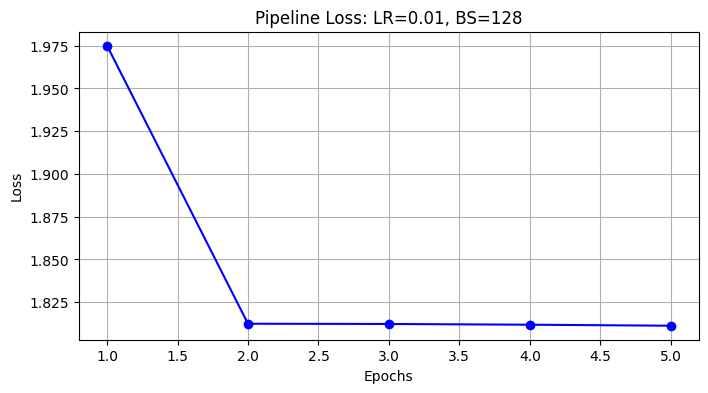

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.01_bs128.pth


epoch,▁▃▅▆█
train_loss,█▁▁▁▁
epoch,5
train_loss,1.81124


wandb: Agent Starting Run: giy3kg95 with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: jumping-sweep-7 | Epoch [1/5], Loss: 1.8649
Run: jumping-sweep-7 | Epoch [2/5], Loss: 1.8117
Run: jumping-sweep-7 | Epoch [3/5], Loss: 1.8111
Run: jumping-sweep-7 | Epoch [4/5], Loss: 1.8110
Run: jumping-sweep-7 | Epoch [5/5], Loss: 1.8112


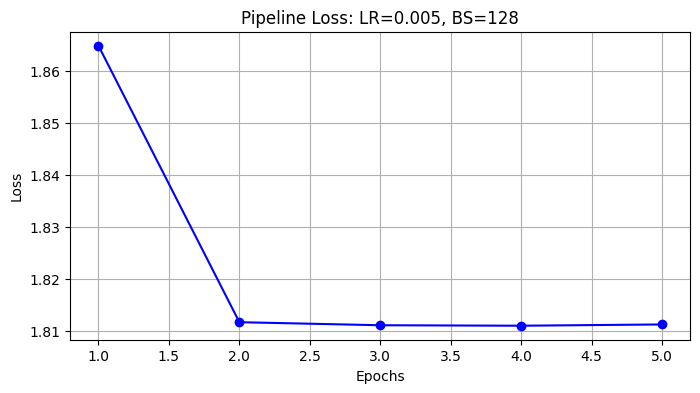

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.005_bs128.pth


epoch,▁▃▅▆█
train_loss,█▁▁▁▁
epoch,5
train_loss,1.81124


wandb: Agent Starting Run: xpqek6yr with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: quiet-sweep-8 | Epoch [1/5], Loss: 1.6074
Run: quiet-sweep-8 | Epoch [2/5], Loss: 1.3964
Run: quiet-sweep-8 | Epoch [3/5], Loss: 1.2824
Run: quiet-sweep-8 | Epoch [4/5], Loss: 1.1971
Run: quiet-sweep-8 | Epoch [5/5], Loss: 1.1054


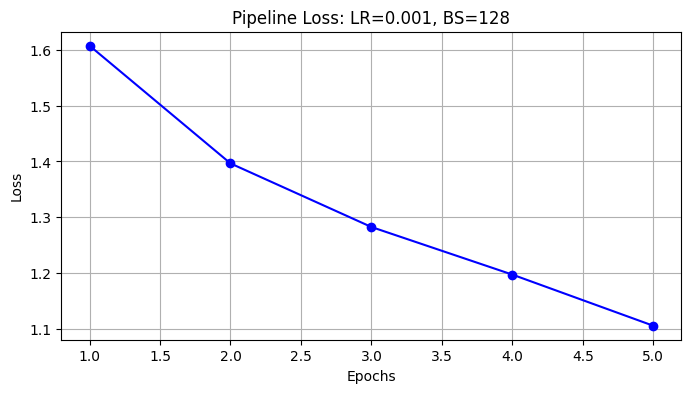

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.001_bs128.pth


epoch,▁▃▅▆█
train_loss,█▅▃▂▁
epoch,5
train_loss,1.10543


wandb: Agent Starting Run: 70nugdhi with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.0005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: misty-sweep-9 | Epoch [1/5], Loss: 1.6583
Run: misty-sweep-9 | Epoch [2/5], Loss: 1.4825
Run: misty-sweep-9 | Epoch [3/5], Loss: 1.3871
Run: misty-sweep-9 | Epoch [4/5], Loss: 1.3152
Run: misty-sweep-9 | Epoch [5/5], Loss: 1.2531


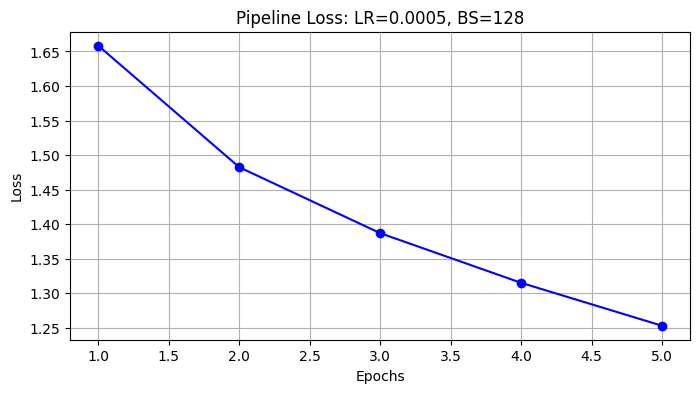

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.0005_bs128.pth


epoch,▁▃▅▆█
train_loss,█▅▃▂▁
epoch,5
train_loss,1.25314


wandb: Agent Starting Run: 53vmzi9y with config:
wandb: 	batch_size: 128
wandb: 	learning_rate: 0.0001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run: volcanic-sweep-10 | Epoch [1/5], Loss: 1.7250
Run: volcanic-sweep-10 | Epoch [2/5], Loss: 1.6068
Run: volcanic-sweep-10 | Epoch [3/5], Loss: 1.5513
Run: volcanic-sweep-10 | Epoch [4/5], Loss: 1.5061
Run: volcanic-sweep-10 | Epoch [5/5], Loss: 1.4647


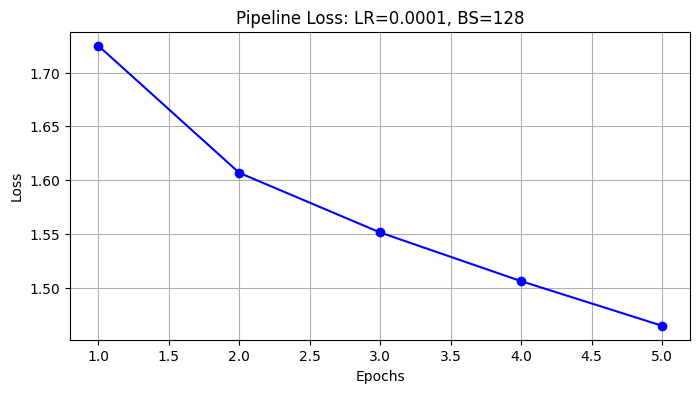

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Logged and saved pipeline version: pipeline_v_lr0.0001_bs128.pth


epoch,▁▃▅▆█
train_loss,█▅▃▂▁
epoch,5
train_loss,1.46467


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x794a3b9429c0>> (for post_run_cell):


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

In [28]:
import matplotlib.pyplot as plt
import wandb
import torch
import torch.nn as nn

# Ensure the pipeline class is defined for the sweep
class FERPipeline(nn.Module):
    def __init__(self, model, transform):
        super(FERPipeline, self).__init__()
        self.model = model
        self.transform = transform

    def forward(self, x):
        return self.model(x)

def train_sweep():
    with wandb.init() as run:
        config = run.config

        # 1. Initialize Model & Pipeline
        sweep_model = BaselineCNN(num_classes=7).to(device)
        sweep_optimizer = optim.Adam(sweep_model.parameters(), lr=config.learning_rate)
        sweep_train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)

        # Create the pipeline instance for this run
        current_pipeline = FERPipeline(sweep_model, val_transform)

        loss_history = []
        num_epochs = 5

        # 2. Training Loop
        for epoch in range(num_epochs):
            sweep_model.train()
            running_loss = 0.0
            for images, labels in sweep_train_loader:
                images, labels = images.to(device), labels.to(device)
                sweep_optimizer.zero_grad()
                outputs = sweep_model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                sweep_optimizer.step()
                running_loss += loss.item()

            avg_loss = running_loss / len(sweep_train_loader)
            loss_history.append(avg_loss)

            wandb.log({"epoch": epoch + 1, "train_loss": avg_loss})
            print(f"Run: {run.name} | Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

        # 3. Visualization
        plt.figure(figsize=(8, 4))
        plt.plot(range(1, num_epochs + 1), loss_history, marker='o', color='b')
        plt.title(f"Pipeline Loss: LR={config.learning_rate}, BS={config.batch_size}")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()

        # 4. Save as Pipeline Version
        model_filename = f"pipeline_v_lr{config.learning_rate}_bs{config.batch_size}.pth"
        torch.save(current_pipeline.state_dict(), model_filename)
        wandb.save(model_filename)
        print(f"Logged and saved pipeline version: {model_filename}")

# Sweep configuration
sweep_config = {
    'method': 'grid',
    'metric': {'name': 'train_loss', 'goal': 'minimize'},
    'parameters': {
        'learning_rate': {"values": [0.01, 0.005, 0.001, 0.0005, 0.0001]},
        'batch_size': {"values": [32, 128]}
    }
}

sweep_id = wandb.sweep(sweep_config, project="facial-expression-recognition")
wandb.agent(sweep_id, function=train_sweep, count=10)